# Otto Group Product Classification with SONN

Downloads the Otto Group dataset from OpenML (ARFF format), performs a stratified
70/15/15 split, trains a SONN multi-class classifier, and reports the official
Kaggle metric (multi-class log loss) on all three splits.

## Imports & path setup

In [1]:
%matplotlib inline

import os
import sys
import tempfile
import urllib.request
from pathlib import Path

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, log_loss

project_root = Path.cwd()
while not (project_root / 'src').is_dir() and project_root != project_root.parent:
    project_root = project_root.parent
src_path = project_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import torchsonn.config  # noqa: F401
from hydra import compose, initialize_config_dir
from omegaconf import OmegaConf
from torch.utils.data import DataLoader
from torchsonn.data.dataset import SONNDataset
from torchsonn.data.preprocessing import train_preprocessing
from torchsonn.logger import setup_logger
from torchsonn.model import SONN
from torchsonn.trainer import Trainer
from sklearn.preprocessing import StandardScaler


## Directories

The dataset is cached in `tutorials/otto/data/` so it is only downloaded once.
Checkpoints and logs go to a throwaway temp directory.

In [2]:
# Notebook outputs are committed to the repo, so anything printed below is
# published with it. Raw absolute paths leak the OS account name (on Windows
# the temp dir is C:\Users\<name>\AppData\Local\Temp), where the project sits
# on disk, and - if the repo lives on a mapped network drive - the file
# server's hostname and share. Route anything that may embed a path through
# redact() before printing or logging it.
import re

# Longest-first: on Windows the temp dir is *inside* the home dir, so it has
# to be substituted before the home-dir rule can shorten its prefix to '~'.
_REDACTIONS = [
    (tempfile.gettempdir(), '<tmp>'),
    (str(project_root.resolve()), '<repo>'),  # UNC form of a mapped drive
    (str(project_root), '<repo>'),            # the mapped drive itself
    (str(Path.home()), '~'),
]


def redact(text: object) -> str:
    """Swap machine-specific path prefixes for stable placeholders."""
    s = str(text)
    for real, label in _REDACTIONS:
        # Match both separator styles: pathlib emits '\', YAML dumps often '/'.
        for variant in {real, real.replace('\\', '/')}:
            s = re.sub(re.escape(variant), label, s, flags=re.IGNORECASE)
    return s

tutorial_dir = (project_root / 'tutorials' / 'otto').resolve()
data_dir = tutorial_dir / 'data'
data_dir.mkdir(exist_ok=True)

tmp_dir  = Path(tempfile.mkdtemp(prefix='otto_sonn_'))
ckpt_dir = tmp_dir / 'checkpoints'
ckpt_dir.mkdir()
log_path = str(tmp_dir / 'train.log')

print(f'tutorial dir : {redact(tutorial_dir)}')
print(f'data cache   : {redact(data_dir)}')
print(f'scratch dir  : {redact(tmp_dir)}')

tutorial dir : <repo>\tutorials\otto
data cache   : <repo>\tutorials\otto\data
scratch dir  : <tmp>\otto_sonn_aox25kdq


## Download & parse dataset

The file is ARFF format. `@ATTRIBUTE` lines name each column; data starts after `@DATA`.
Column 0 is the sample ID (dropped); the last column is the class label `Class_1`…`Class_9`.

In [3]:
DATASET_URL = 'https://api.openml.org/data/download/22116516/dataset'
CACHE_FILE  = data_dir / 'otto_dataset.arff'

def _progress(block_num, block_size, total_size):
    if total_size > 0:
        pct = min(100, block_num * block_size * 100 // total_size)
        print(f'\rDownloading... {pct}%', end='', flush=True)

if not CACHE_FILE.exists():
    print(f'Downloading from {DATASET_URL}')
    urllib.request.urlretrieve(DATASET_URL, CACHE_FILE, reporthook=_progress)
    print(f'\nSaved to {redact(CACHE_FILE)} ({CACHE_FILE.stat().st_size / 1e6:.1f} MB)')
else:
    print(f'Using cached file: {redact(CACHE_FILE)} ({CACHE_FILE.stat().st_size / 1e6:.1f} MB)')

with open(CACHE_FILE, 'r') as f:
    lines = f.readlines()

attr_names, data_start = [], None
for i, line in enumerate(lines):
    s = line.strip()
    if s.upper() == '@DATA':
        data_start = i + 1
        break
    if s.upper().startswith('@ATTRIBUTE'):
        attr_names.append(s.split()[1])

assert data_start is not None, '@DATA marker not found'

rows, labels = [], []
for line in lines[data_start:]:
    s = line.strip()
    if not s or s.startswith('%'):
        continue
    parts = s.split(',')
    rows.append(list(map(float, parts[1:-1])))
    labels.append(int(parts[-1].strip().split('_')[1]) - 1)

X = np.array(rows,   dtype=np.float32)
y = np.array(labels, dtype=np.int64)
feature_names = attr_names[1:-1]  # col 0 = id, col -1 = class
CLASS_NAMES   = [f'Class_{i+1}' for i in range(9)]

print(f'X shape      : {X.shape}')
print(f'y shape      : {y.shape}')
print(f'features     : {len(feature_names)}')
print(f'classes      : {sorted(set(labels))}')

Using cached file: <repo>\tutorials\otto\data\otto_dataset.arff (12.4 MB)
X shape      : (61878, 93)
y shape      : (61878,)
features     : 93
classes      : [0, 1, 2, 3, 4, 5, 6, 7, 8]


## Load config

In [4]:
with initialize_config_dir(version_base='1.3', config_dir=str(tutorial_dir)):
    config = compose(config_name='otto')

config.train.checkpoint_dir = str(ckpt_dir)

logger = setup_logger(log_path)
logger.info(redact(OmegaConf.to_yaml(config)))
print(redact(OmegaConf.to_yaml(config)))

2026-05-21 19:04:51,463 - INFO - root - model:
  type: multi-class
  soft_binner: false
  soft_binner_scale: 100.0
  num_classes: 9
  ref_functions:
  - polyquad:
    - squares: true
    - dim: 5
  shortcut: true
  normalize: true
  activation: ''
  nbest_neurons: 93
  max_neuron_models: 10000
  use_output_projection: true
  num_out_neurons: 93
  use_neuron_proj: true
  output_clamp_value: 1000.0
  use_layer_norm: false
train:
  seed: 42
  criterion_type: validate
  bias_ce_type: js
  error_alpha: 0.5
  max_layer_count: 3
  criterion_minimum_width: 5
  stop_train_epsilon_condition: 0.0001
  manual_best_neurons_selection: false
  min_best_neurons_count: 0
  max_best_neurons_count: 0
  layer_err_criterion: top
  neuron_selection_method: omp_mixed
  neuron_selection_orth_threshold: 0.2
  eval_step_interval: 100
  eval_smoothing_factor: 0.2
  save_interval: 1000
  save_last_layer: true
  keep_last_n: 10
  skip_saving_at_epoch_end: true
  checkpoint_dir: <tmp>\otto_sonn_aox25kdq\checkpoints

## Stratified 70 / 15 / 15 split

`train_test_split(stratify=y)` ensures every class is proportionally represented
in every split. The table below confirms the distribution.

In [5]:
X_train, X_rem, y_train, y_rem = train_test_split(
    X, y, test_size=0.30, random_state=config.train.seed, stratify=y
)
X_dev, X_test, y_dev, y_test = train_test_split(
    X_rem, y_rem, test_size=0.50, random_state=config.train.seed, stratify=y_rem
)

print(f'train : {X_train.shape[0]:>6}   dev : {X_dev.shape[0]:>5}   test : {X_test.shape[0]:>5}')
print()
print(f'{"Class":<10} {"Train":>8} {"Dev":>8} {"Test":>8}')
print('-' * 38)
for c in range(9):
    print(f'{CLASS_NAMES[c]:<10} {(y_train==c).sum():>8} {(y_dev==c).sum():>8} {(y_test==c).sum():>8}')

train :  43314   dev :  9282   test :  9282

Class         Train      Dev     Test
--------------------------------------
Class_1        1350      289      290
Class_2       11285     2419     2418
Class_3        5603     1201     1200
Class_4        1884      403      404
Class_5        1917      411      411
Class_6        9894     2120     2121
Class_7        1987      426      426
Class_8        5925     1270     1269
Class_9        3469      743      743


## Preprocessing & DataLoaders

In [6]:
x_train, y_train = train_preprocessing(X_train, y_train, feature_names)
x_dev,   y_dev   = train_preprocessing(X_dev,   y_dev,   feature_names)
x_test,  y_test  = train_preprocessing(X_test,  y_test,  feature_names)

# Otto features are integer counts with very heavy tails. log1p compresses
# them so StandardScaler isn't dominated by a handful of large values.
x_train = np.log1p(x_train)
x_dev   = np.log1p(x_dev)
x_test  = np.log1p(x_test)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_dev   = scaler.transform(x_dev)
x_test  = scaler.transform(x_test)

bs = config.train.batch_size
train_dl = DataLoader(SONNDataset(x_train, y_train), batch_size=bs, shuffle=True)
dev_dl   = DataLoader(SONNDataset(x_dev,   y_dev),   batch_size=bs)
test_dl  = DataLoader(SONNDataset(x_test,  y_test),  batch_size=bs)

print(f'train batches: {len(train_dl)}   dev: {len(dev_dl)}   test: {len(test_dl)}')

train batches: 85   dev: 19   test: 19


## Class weights

Otto is heavily imbalanced — `Class_2` and `Class_6` together account for ~50 % of
the data, while `Class_1` is under 3 %. Without per-class weighting in the loss,
both the per-layer ensemble and the final `out_proj` head learn to predict the
majority class for almost everything. We compute inverse-frequency weights
(`N / (K · count_k)`, matching sklearn's `class_weight='balanced'`) and hand them
to the `Trainer`, which propagates them into `model.loss_fn = NLLLoss(weight=cw)`.

In [7]:
counts = np.bincount(y_train)
cw = torch.tensor(counts.sum() / (len(counts) * counts), dtype=torch.float32)
print('class weights:', cw.numpy().round(3))

class weights: [3.565 0.426 0.859 2.554 2.511 0.486 2.422 0.812 1.387]


## Build model

In [8]:
# Input-side LayerNorm (no learnable params) — runs every batch through a
# per-sample standardization before the first polynomial layer. Keeps the
# StandardScaler's per-feature centering even when the dataloader's batches
# happen to deviate from the training-set marginals.
preprocessing = torch.nn.Sequential(
    torch.nn.LayerNorm(x_train.shape[1], elementwise_affine=False)
)

model = SONN(
    config,
    d_model=x_train.shape[1],
    feature_names=feature_names,
    preprocessing=preprocessing,
)
model = model.to(config.train.device)
model

SONN(
  (preprocessing): Sequential(
    (0): LayerNorm((93,), eps=1e-05, elementwise_affine=False)
  )
  (layers): ModuleList()
  (loss_fn): NLLLoss()
  (out_proj): Linear(in_features=93, out_features=9, bias=True)
)

## Train

In [9]:
trainer = Trainer(config, feature_names=feature_names, class_weights=cw)
Trainer.set_seed(config.train.seed)
trainer.train(model, train_dl, dev_dl, test_dl, resume=config.resume)

2026-05-21 19:04:51,871 - INFO - torchsonn.model - Creating layer #0
2026-05-21 19:04:51,917 - INFO - torchsonn.trainer - Training layer #0
2026-05-21 19:05:09,689 - INFO - torchsonn.trainer - All models of PolyQuadratic early stopped at step 1100                                       
Training: 100%|██████████| 1100/1100 [00:17<00:00, 61.86it/s, epoch=12, step=1100, lr=1.00e-03, val_loss=[1.614, 2.033, 2.175], completed=0/10000]
2026-05-21 19:05:11,809 - INFO - torchsonn.trainer - [layer 0] correlation off-diagonal — median |ρ|: 0.434, max: 0.952
2026-05-21 19:05:11,826 - INFO - torchsonn.trainer - [layer 0] top 10 singular values: [3662.34158745 1999.47377932 1471.96744972 1398.11227323 1199.72312964
 1034.89007541  818.44701142  703.00438228  658.92575175  585.65089828]
2026-05-21 19:05:11,826 - INFO - torchsonn.trainer - [layer 0] effective rank (>1% of top): 93
2026-05-21 19:05:11,826 - INFO - torchsonn.trainer - Current layer error: 0.832
2026-05-21 19:05:11,826 - INFO - torchson

SONN(
  (preprocessing): Sequential(
    (0): LayerNorm((93,), eps=1e-05, elementwise_affine=False)
  )
  (layers): ModuleList(
    (0): Layer 0
    (1): Layer 1
    (2): Layer 2
  )
  (loss_fn): NLLLoss()
  (out_proj): Linear(in_features=93, out_features=9, bias=True)
)

## Train the output head

`trainer.train(...)` grows and selects the polynomial layers, but the final
`out_proj` Linear(d, num_classes) head only had per-layer fine-tune temporary
heads fitted against it (and those were discarded). This step trains the
real, persistent `out_proj` against class-weighted CE on the dev split. The
trainer also re-saves `model_last.ckpt` at the end of this call so the next
`load_model_checkpoint` brings the trained head back instead of the random
initialization that was persisted during `train()`.

In [10]:
if model.out_proj is not None:
    print('Training out_proj...')
    trainer.train_out_proj(model, train_dl, dev_dl)
else:
    print('Model has no out_proj — set model.use_output_projection=true in the YAML to enable it.')

Training out_proj...
2026-05-21 19:06:55,626 - INFO - torchsonn.trainer - out_proj (lbfgs) early stop at step 80 — no improvement for 10 evals                   
out_proj (lbfgs): 100%|█████████████████████████| 80/80 [00:06<00:00, 12.10it/s, train_loss=0.5536, val_loss=0.8099, best=0.7909, no_imp=10]


## Load best checkpoint & evaluate

In [11]:
trainer.load_model_checkpoint(model, config.train.device)
model_out, tgt = trainer.infer(model, test_dl)

pred = model_out.argmax(dim=1).cpu().numpy()
true = tgt.cpu().numpy()

print(f'Test accuracy: {(pred == true).mean():.4f}')
print()
print(classification_report(true, pred, target_names=CLASS_NAMES))

19it [00:00, 123.45it/s]

Test accuracy: 0.7329

              precision    recall  f1-score   support

     Class_1       0.43      0.68      0.53       290
     Class_2       0.81      0.56      0.67      2418
     Class_3       0.49      0.60      0.54      1200
     Class_4       0.38      0.70      0.49       404
     Class_5       0.92      0.97      0.94       411
     Class_6       0.95      0.87      0.91      2121
     Class_7       0.50      0.74      0.60       426
     Class_8       0.90      0.85      0.87      1269
     Class_9       0.80      0.83      0.82       743

    accuracy                           0.73      9282
   macro avg       0.69      0.75      0.71      9282
weighted avg       0.77      0.73      0.74      9282



## Official score: multi-class log loss

The Kaggle Otto competition metric is **multi-class log loss** (lower = better).
The model outputs log-softmax values; `torch.exp()` converts them to the
probabilities that `log_loss` expects.

In [12]:
def _logloss(dl, label):
    out, tgt = trainer.infer(model, dl, verbose=False)
    proba = torch.exp(out).cpu().numpy()
    true  = tgt.cpu().numpy()
    ll    = log_loss(true, proba)
    acc   = (proba.argmax(axis=1) == true).mean()
    print(f'{label:<8}  log_loss = {ll:.4f}   accuracy = {acc:.4f}')
    return ll

print(f"{'Split':<8}  {'Log Loss':>12}   {'Accuracy':>10}")
print('-' * 38)
ll_train = _logloss(train_dl, 'Train')
ll_dev   = _logloss(dev_dl,   'Dev')
ll_test  = _logloss(test_dl,  'Test')

Split         Log Loss     Accuracy
--------------------------------------
Train     log_loss = 0.6145   accuracy = 0.7586
Dev       log_loss = 0.7260   accuracy = 0.7265
Test      log_loss = 0.7308   accuracy = 0.7329


## Confusion matrix

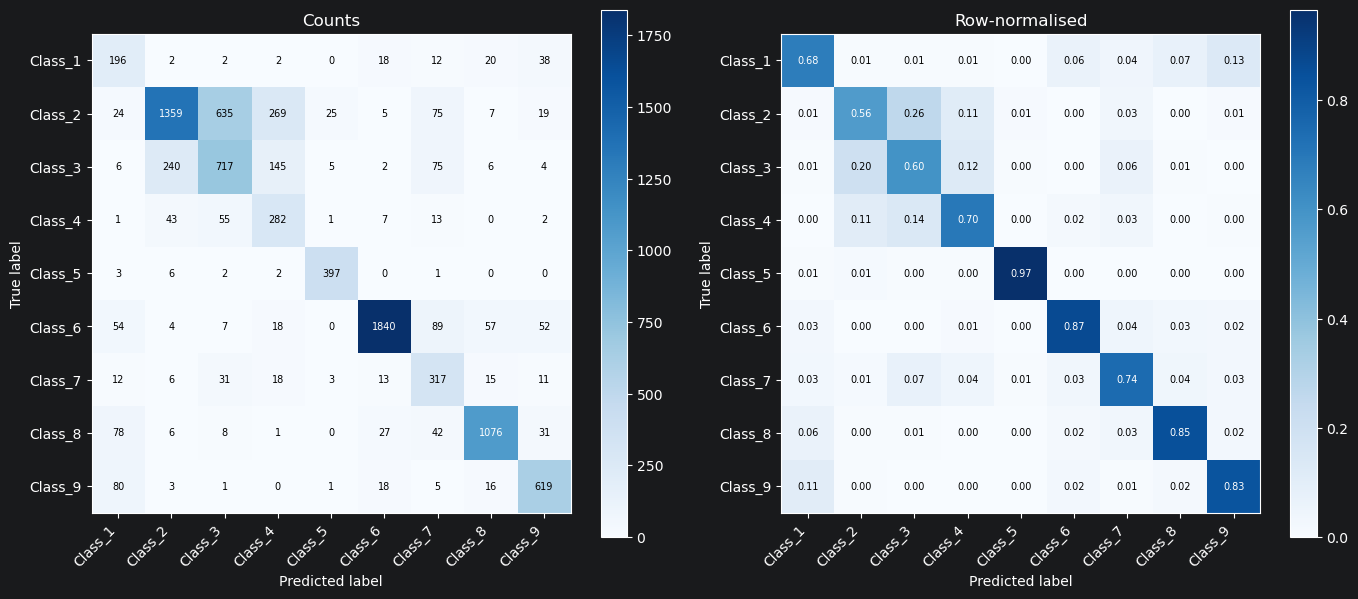

In [13]:
cm      = confusion_matrix(true, pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, data, title, fmt in zip(
    axes, [cm, cm_norm], ['Counts', 'Row-normalized'], ['d', '.2f']
):
    im = ax.imshow(data, interpolation='nearest', cmap=plt.cm.Blues)
    plt.colorbar(im, ax=ax)
    ax.set(title=title, xticks=range(9), yticks=range(9),
           xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
           ylabel='True label', xlabel='Predicted label')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    thresh = data.max() / 2
    for i in range(9):
        for j in range(9):
            ax.text(j, i, format(data[i, j], fmt),
                    ha='center', va='center', fontsize=7,
                    color='white' if data[i, j] > thresh else 'black')
plt.tight_layout()
plt.show()

## Layer-error curve

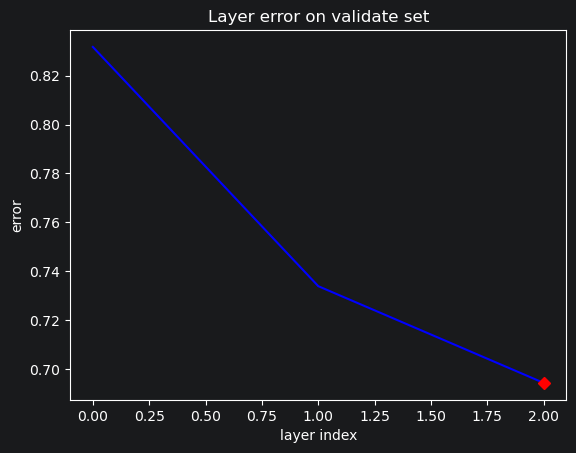

In [14]:
model.plot_layer_error()
plt.show()

## Final scores

Log loss and accuracy on every split after training is complete.

In [15]:
results = {}
for dl, label in [(train_dl, 'Train'), (dev_dl, 'Dev'), (test_dl, 'Test')]:
    out, tgt = trainer.infer(model, dl, verbose=False)
    proba = torch.exp(out).cpu().numpy()
    true_np = tgt.cpu().numpy()
    results[label] = dict(
        log_loss = log_loss(true_np, proba),
        accuracy = (proba.argmax(axis=1) == true_np).mean(),
    )

print(f"{'Split':<8}  {'Log Loss':>10}  {'Accuracy':>10}")
print('-' * 34)
for label, m in results.items():
    print(f"{label:<8}  {m['log_loss']:>10.4f}  {m['accuracy']:>10.4f}")

Split       Log Loss    Accuracy
----------------------------------
Train         0.6145      0.7586
Dev           0.7260      0.7265
Test          0.7308      0.7329


## Cleanup (optional)

In [16]:
# import shutil
# shutil.rmtree(tmp_dir)
# print(f'removed {redact(tmp_dir)}')